In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('bd_students_per_v2.csv')
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,guardian,parental_involvement,internet_access,studytime,tutoring,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,Father,Yes,Yes,8,Yes,Private,95,Yes,95,98,92,94,98,Science
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,Father,Yes,No,4,No,Semi_Govt,92,No,65,71,40,78,80,Commerce
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,Father,Yes,Yes,5,Yes,Govt,81,Yes,64,78,58,86,74,Commerce
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,Father,Yes,Yes,7,Yes,Private,90,Yes,84,90,85,86,88,Science
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,Father,Yes,Yes,4,Yes,Semi_Govt,75,Yes,54,70,45,79,76,Commerce


In [6]:
print("Shape:", df.shape)
df.info()

# Missing values & duplicates
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Clean inconsistent text values
df['location'] = df['location'].str.strip().str.title()
df['mother_education'] = df['mother_education'].replace({'Hons': 'Honors'})
df['father_education'] = df['father_education'].replace({'Hons': 'Honors'})

Shape: (8612, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 24 columns):
id                             8612 non-null int64
full_name                      8612 non-null object
age                            8612 non-null int64
gender                         8612 non-null object
location                       8611 non-null object
family_size                    8612 non-null int64
mother_education               8612 non-null object
father_education               8612 non-null object
mother_job                     8612 non-null object
father_job                     8612 non-null object
guardian                       8612 non-null object
parental_involvement           8612 non-null object
internet_access                8612 non-null object
studytime                      8612 non-null int64
tutoring                       8612 non-null object
school_type                    8612 non-null object
attendance                     8612 non-null in

AttributeError: module 'seaborn' has no attribute 'histplot'

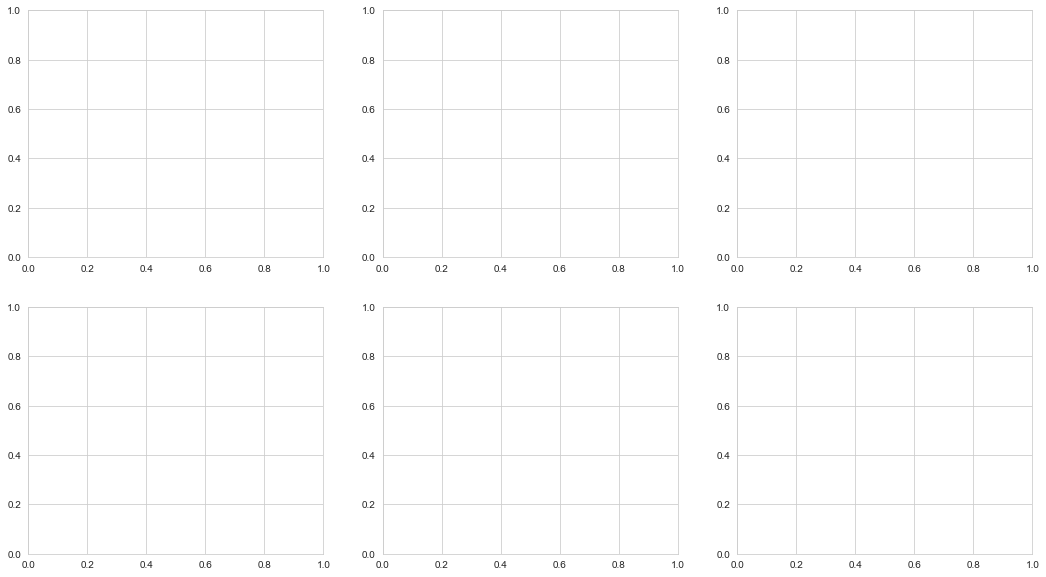

In [7]:
subjects = ['english', 'math', 'science', 'social_science', 'art_culture']
df['avg_score'] = df[subjects].mean(axis=1)

df[subjects].describe()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, sub in enumerate(subjects):
    sns.histplot(df[sub], bins=25, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'{sub.title()} Distribution')
plt.tight_layout()
plt.show()

           english  math  science  social_science  art_culture  avg_score
stu_group                                                                
Arts          56.1  55.1     56.1            57.7         62.0       57.4
Commerce      74.5  73.5     74.3            75.6         76.4       74.9
Science       88.9  88.9     88.8            88.9         89.3       88.9


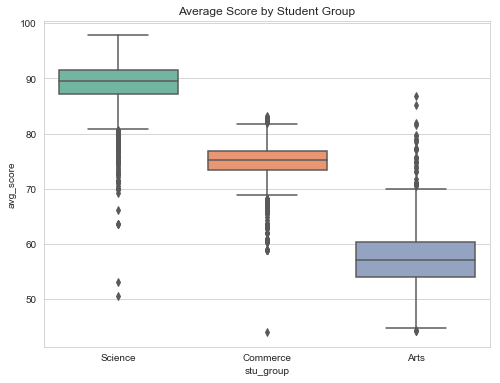

In [8]:
group_avg = df.groupby('stu_group')[subjects + ['avg_score']].mean().round(1)
print(group_avg)

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='stu_group', y='avg_score', palette='Set2')
plt.title('Average Score by Student Group')
plt.show()

In [9]:
for col in ['tutoring', 'gender', 'school_type', 'internet_access', 'parental_involvement']:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['avg_score'].mean().round(2))


--- tutoring ---
tutoring
No     73.74
Yes    74.54
Name: avg_score, dtype: float64

--- gender ---
gender
Female    74.07
Male      74.24
Name: avg_score, dtype: float64

--- school_type ---
school_type
Govt         74.27
Private      77.00
Semi_Govt    71.81
Name: avg_score, dtype: float64

--- internet_access ---
internet_access
No     73.89
Yes    74.38
Name: avg_score, dtype: float64

--- parental_involvement ---
parental_involvement
No     74.00
Yes    74.29
Name: avg_score, dtype: float64


In [ ]:
#Visualization

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('bd_students_per_v2.csv')

# Cleaning
df['location'] = df['location'].str.strip().str.title()
df['mother_education'] = df['mother_education'].replace({'Hons': 'Honors'})
df['father_education'] = df['father_education'].replace({'Hons': 'Honors'})

subjects = ['english', 'math', 'science', 'social_science', 'art_culture']
df['avg_score'] = df[subjects].mean(axis=1)

AttributeError: module 'seaborn' has no attribute 'histplot'

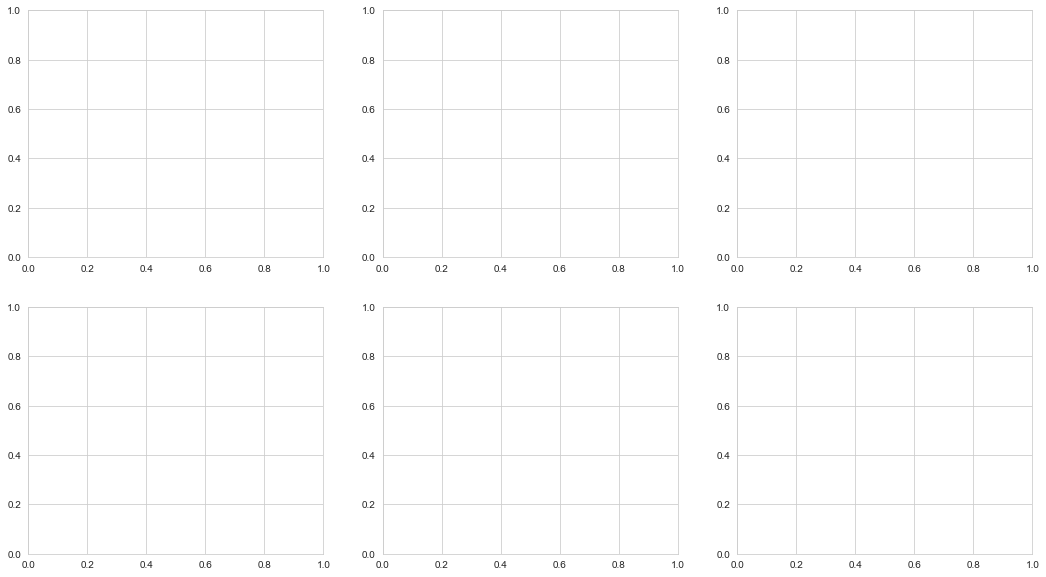

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sub in enumerate(subjects):
    sns.histplot(df[sub], bins=25, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'{sub.title()} Score Histogram')
    axes[i].axvline(df[sub].mean(), color='red', linestyle='--')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

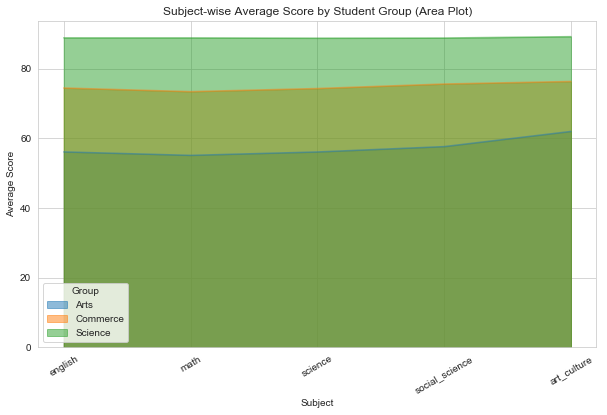

In [14]:
# Average marks per subject by student group, as an area plot
group_avg = df.groupby('stu_group')[subjects].mean()

group_avg.T.plot(kind='area', alpha=0.5, figsize=(10,6), stacked=False)
plt.title('Subject-wise Average Score by Student Group (Area Plot)')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.xticks(range(len(subjects)), subjects, rotation=30)
plt.legend(title='Group')
plt.show()

C:\Users\Dell\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


AttributeError: Unknown property errorbar

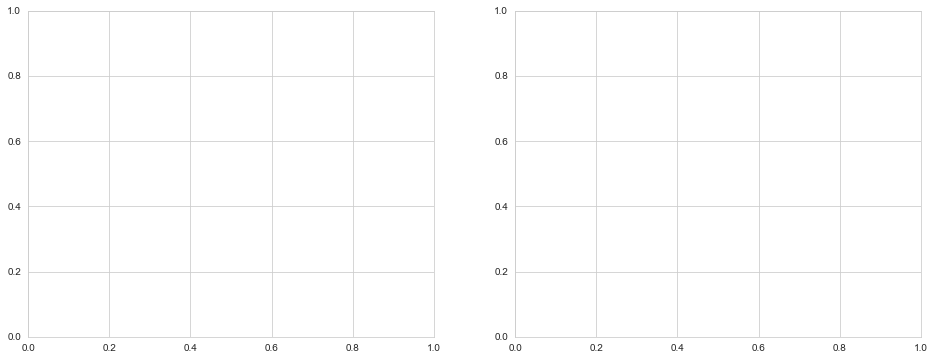

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.barplot(data=df, x='stu_group', y='avg_score', ax=axes[0], palette='Set2', errorbar=None)
axes[0].set_title('Average Score by Student Group')

sns.barplot(data=df, x='school_type', y='avg_score', ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('Average Score by School Type')

plt.tight_layout()
plt.show()

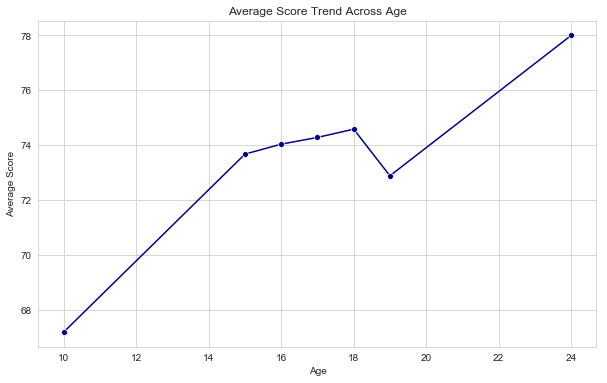

In [16]:
# Average score trend across age
age_trend = df.groupby('age')['avg_score'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=age_trend, x='age', y='avg_score', marker='o', color='darkblue')
plt.title('Average Score Trend Across Age')
plt.xlabel('Age')
plt.ylabel('Average Score')
plt.show()

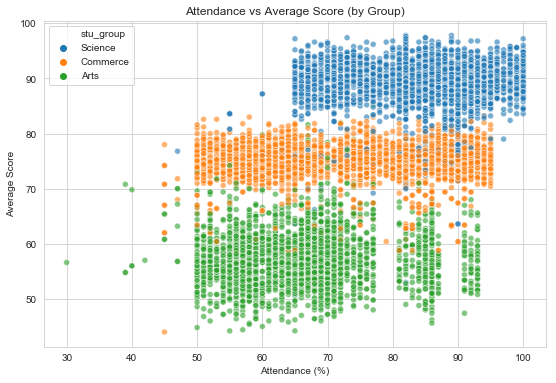

In [17]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='attendance', y='avg_score', hue='stu_group', alpha=0.6)
plt.title('Attendance vs Average Score (by Group)')
plt.xlabel('Attendance (%)')
plt.ylabel('Average Score')
plt.show()